# CLASSIFICATION USING THE TITANIC DATASET

Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

Load Dataset

In [2]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Explore Dataset

In [3]:
print(df.shape)

df.info()

df.describe()

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Check Missing Values

In [4]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Clean Dataset

In [5]:
# Remove column with excessive missing values

df.drop(columns=["deck"], inplace=True)

# Fill missing numerical values

df["age"] = df["age"].fillna(df["age"].median())

# Fill missing categorical values

df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

Select Features

In [6]:
X = df[[
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]]

y = df["survived"]

Encode Categorical Variables

In [7]:
X = pd.get_dummies(
    X,
    drop_first=True
)

Split Dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Train Logistic Regression Model

In [9]:
model = LogisticRegression(max_iter=1000)

model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

Make Predictions

In [10]:
y_pred = model.predict(X_test)

Evaluate Model:
Accuracy

In [11]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


Precision

In [12]:
print(
    precision_score(
        y_test,
        y_pred
    )
)

0.7857142857142857


Recall

In [13]:
print(
    recall_score(
        y_test,
        y_pred
    )
)

0.7432432432432432


F1 Score

In [14]:
print(
    f1_score(
        y_test,
        y_pred
    )
)

0.7638888888888888


Classification Report

In [15]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Plot Confusion Matrix

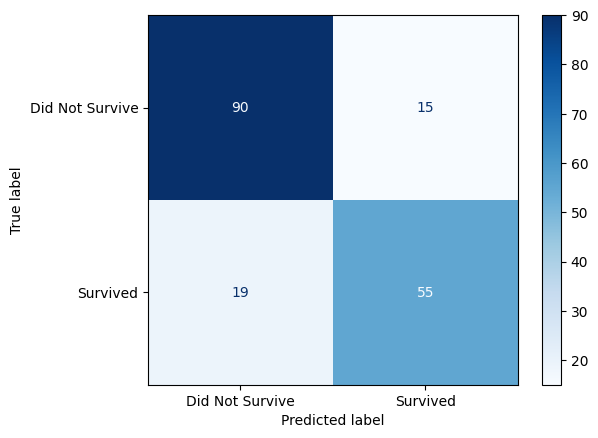

In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Did Not Survive",
        "Survived"
    ]
)

disp.plot(cmap="Blues")

plt.show()

# REGRESSION USING CALIFORNIA HOUSING DATASET

Import Dataset

In [17]:
from sklearn.datasets import fetch_california_housing

Load Dataset

In [18]:
housing = fetch_california_housing()

housing_df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

housing_df["Price"] = housing.target

housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Explore Dataset

In [19]:
housing_df.info()

housing_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Select Features

In [20]:
X = housing_df.drop(
    "Price",
    axis=1
)

y = housing_df["Price"]

Split Dataset

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Import Linear Regression

In [22]:
from sklearn.linear_model import LinearRegression

Train Model

In [23]:
regression = LinearRegression()

regression.fit(
    X_train,
    y_train
)

LinearRegression()

Make Predictions

In [24]:
predictions = regression.predict(
    X_test
)

Evaluate Model

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Mean Absolute Error

In [26]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print(mae)

0.5332001304956553


Mean Squared Error

In [27]:
mse = mean_squared_error(
    y_test,
    predictions
)

print(mse)

0.5558915986952444


Root Mean Squared Error

In [28]:
rmse = np.sqrt(mse)

print(rmse)

0.7455813830127764


R² Score

In [29]:
r2 = r2_score(
    y_test,
    predictions
)

print(r2)

0.5757877060324508


Plot Actual vs Predicted Values

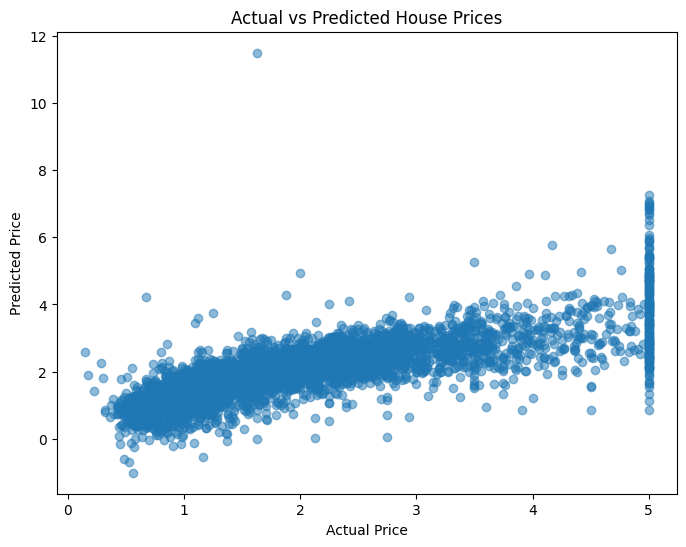

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

Feature Importance (Regression Coefficients)

In [31]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": regression.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


Plot Regression Coefficients

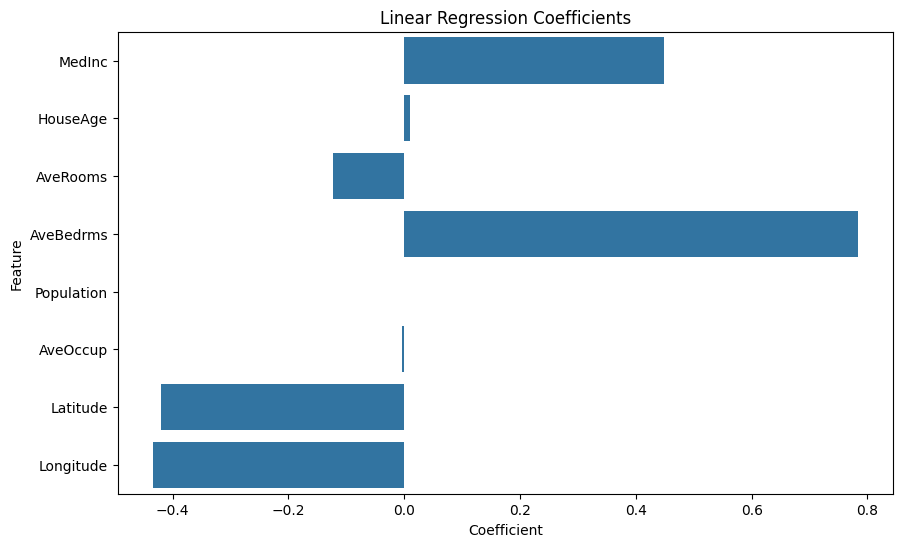

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Coefficients")

plt.show()

**Classification Results:**
The Logistic Regression model was trained to predict whether a passenger survived based on passenger characteristics. Model performance was evaluated using Accuracy, Precision, Recall, F1-score, and a Confusion Matrix.

**Regression Results:**
The Linear Regression model was trained to predict median house prices using housing characteristics. Performance was evaluated using MAE, MSE, RMSE, and R² Score. The Actual vs Predicted plot illustrates how closely predictions match the observed values.

Save Classification Model

In [33]:
import joblib

joblib.dump(
    model,
    "titanic_classifier.pkl"
)

['titanic_classifier.pkl']

Save Regression Model

In [34]:
joblib.dump(
    regression,
    "housing_regression.pkl"
)

['housing_regression.pkl']